# NYT Connections Puzzle Solver
## DATA 620 Final Project

Authors: Kevin Havis and Aaliyah John-Harry

## Introduction

The New York Times hosts several puzzle games on its website, but perhaps the most popular is Connections.

Connections is a word game where the player is given sixteen words and must group them into four categories of four words each based on hidden relationships or implicit patterns.

These relationships may be semantic, structural (prefixes/suffixes), or cultural references. The puzzle is intentionally designed to mislead players with plausible but incorrect groupings. In practice, players look for logical groups of four words, progressively eliminating words as they get the groupings correct.

Our goal is to develop a model that can automatically group the sixteen words into their correct categories using a combination of natural language processing (NLP) and network analysis techniques.

### Research Question
Can semantic embeddings and similarity-based grouping recover NYT Connections categories better than random guessing, and how can network graphs help visualize these relationships?

### Hypothesis
We expect that combining word embeddings with network-based clustering will outperform both random grouping and simple cosine similarity, approaching human-level performance on historical puzzles.

### Potential Challenges/Concerns

- The primary challenge is the diversity of relationships between words.
    - Simple methods such as cosine similarity may capture semantic meaning but fail to detect structural or contextual patterns.
    - Additionally, the puzzle often intentionally misdirects the player by providing words that can be intuitively grouped but do not fit the predetermined category.
- Categories may rely on cultural knowledge not captured by NLP techniques.
    - Additionally, clustering evaluation is complex due to multiple plausible groupings. 

### Approach

We have several tools we can use to take on this problem.

#### Data

We will use historical NYT Connections puzzles and their solutions from a public GitHub dataset maintained by *Eyefyre* on [GitHub](https://github.com/Eyefyre/NYT-Connections-Answers).


#### Techniques

We must use a combination of techniques to address all potential "angles" of word classification.

- Word Embeddings: Vectorizing the words can give us some initial groupings of similar words by common language 
- Text Processing: Stemming and lemmatization will be used to identify structural relationships.
- Network analysis: Modeling the words as nodes and their connections as edges is a natural approach to this type of "neighbor" clustering

#### Evaluation

Model evaluation for clustering can be challenging; to measure our model's performance, we will compare against the following benchmarks.

- Random Association: Random grouping of words, measured by accuracy
- Simple Word Vector Embeddings: Groups based on semantic similarity.
- LLM Performance: Human-equivalent or better performance
- Human Benchmark: Comparison against known puzzle solutions.

Performance will be measured based on how accurately the model reproduces the correct groupings.

### Roles and Responsibilities

- Aaliyah John-Harry:
    - Text preprocessing
    - Feature engineering
    - Model development
- Kevin Havis:
    - Network construction
    - Graph analysis
    - Clustering methods
- Both:
    - Evaluation
    - Interpretation
    - Presentation

In [6]:
import os, sys

for candidate in [os.getcwd(), os.path.join(os.getcwd(), "project4")]:
    if os.path.isdir(candidate) and candidate not in sys.path:
        sys.path.insert(0, candidate)

print(os.getcwd())
print(sys.path[:3])

c:\Users\Kevin\projects\data_620
['c:\\Users\\Kevin\\projects\\data_620\\project4', 'c:\\Users\\Kevin\\projects\\data_620', 'C:\\Users\\Kevin\\AppData\\Roaming\\uv\\python\\cpython-3.12.9-windows-x86_64-none\\python312.zip']


In [26]:
import pandas as pd
import gensim.downloader as api
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.figure import Figure
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from itertools import combinations
import pandas as pd
import requests
import random
import networkx as nx
from matplotlib.patches import Patch

## DataLoader

The `DataLoader` class is responsible for retrieving and organizing the NYT Connections dataset.

It loads the historical puzzles, stores the raw puzzle structure, and extracts the words into formats that are easier to use throughout the analysis.

In [8]:
class DataLoader:
    def __init__(self):
        self.url = "https://raw.githubusercontent.com/Eyefyre/NYT-Connections-Answers/refs/heads/main/connections.json"
        self.raw: list[dict]
        self.df: pd.DataFrame
        self.words: list[list[str]]
        self.load()

    def load(self) -> None:
        response = requests.get(self.url)
        response.raise_for_status()
        data: list[dict] = response.json()
        self.raw = data
        self.words = [
            [word for answer in puzzle["answers"] for word in answer["members"]]
            for puzzle in data
        ]
        self.df = pd.json_normalize(data, record_path=["answers"], meta=["id", "date"])
        self.df["date"] = pd.to_datetime(self.df["date"])

    def get_puzzle(self, index):
        """
        Returns one puzzle dictionary.
        """
        return self.raw[index]

In [9]:
loader = DataLoader()
df = loader.df

In [10]:
puzzle_index = 0

raw_puzzle = loader.get_puzzle(puzzle_index)
words = loader.words[puzzle_index]

print(words)

['HAIL', 'RAIN', 'SLEET', 'SNOW', 'BUCKS', 'HEAT', 'JAZZ', 'NETS', 'OPTION', 'RETURN', 'SHIFT', 'TAB', 'KAYAK', 'LEVEL', 'MOM', 'RACECAR']


## Embedder

The `Embedder` class converts puzzle words into GloVe vector embeddings and computes cosine similarity between words.

These similarity scores serve as the foundation of our semantic ranking approach and help identify related word groups.

In [11]:
# Will need to download and cache on first run
GLOVE = api.load("glove-wiki-gigaword-300")


class Embedder:
    def __init__(self, words: list[str]):
        self.words = words
        self.glove = GLOVE
        self.embeddings: np.ndarray | None = None
        self.similarity_matrix: np.ndarray | None = None
        self.sample_puzzle: list[str] = [
            "club",
            "diamond",
            "heart",
            "spade",
            "sandwich",
            "knuckle",
            "open",
            "ham",
            "ace",
            "king",
            "queen",
            "jack",
            "flush",
            "straight",
            "full",
            "royal",
        ]

    def get_glove_embeddings(self) -> np.ndarray:
        "Load GloVe word embeddings"

        vectors = []

        for word in self.words:
            w = word.lower().replace(" ", "_")
            if w in self.glove:
                vectors.append(self.glove[w])
            else:
                vectors.append(np.zeros(300))  # GLoVE vectors are 300

        self.embeddings = np.array(vectors)

        return self.embeddings

    def get_cosine_similarity(self) -> np.ndarray:
        if self.embeddings is None:
            raise ValueError("No embeddings found")

        if isinstance(self.embeddings, np.ndarray):
            self.similarity_matrix = cosine_similarity(self.embeddings)
            return self.similarity_matrix
        else:
            raise ValueError(
                "Could not compute similarity matrix with current embeddings"
            )

    def plot_similarity_matrix(self) -> Figure:
        if self.similarity_matrix is None:
            raise ValueError("No similarity matrix found")

        n = len(self.words)
        fig, ax = plt.subplots(figsize=(max(6, n * 0.6), max(5, n * 0.6)))
        sns.heatmap(
            self.similarity_matrix,
            xticklabels=self.words,
            yticklabels=self.words,
            vmin=-1,
            vmax=1,
            center=0,
            cmap="coolwarm",
            annot=n <= 20,
            fmt=".2f",
            square=True,
            linewidths=0.5,
            ax=ax,
        )
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
        ax.set_title("Cosine Similarity Matrix")
        fig.tight_layout()
        return fig

    def demo(self):
        self.words = self.sample_puzzle

        print(f"Words: {self.words}")
        print(f"\nLoading GloVe embeddings for {len(self.words)} words...")
        self.get_glove_embeddings()
        assert self.embeddings is not None
        print(f"Embeddings shape: {self.embeddings.shape}")

        print("\nComputing cosine similarity matrix...")
        self.get_cosine_similarity()
        print("Similarity matrix:")
        print(self.similarity_matrix)

        print("\nPlotting similarity matrix...")
        self.plot_similarity_matrix()
        plt.show()


def mean_pairwise_similarity(indices, similarity_matrix):
    """
    Computes mean cosine similarity across all pairs in a group.
    """
    pair_scores = []

    for i, j in combinations(indices, 2):
        pair_scores.append(similarity_matrix[i, j])

    return np.mean(pair_scores)


def rank_word_combinations(words, similarity_matrix):
    """
    Scores every possible 4-word combination.
    """
    rows = []

    for combo_indices in combinations(range(len(words)), 4):
        combo_words = tuple(words[i] for i in combo_indices)

        score = mean_pairwise_similarity(combo_indices, similarity_matrix)

        rows.append(
            {
                "combo_words": combo_words,
                "combo_indices": combo_indices,
                "mean_cosine_similarity": score,
            }
        )

    ranked_df = pd.DataFrame(rows)

    ranked_df = ranked_df.sort_values(
        by="mean_cosine_similarity", ascending=False
    ).reset_index(drop=True)

    return ranked_df

[==================================================] 100.0% 376.1/376.1MB downloaded


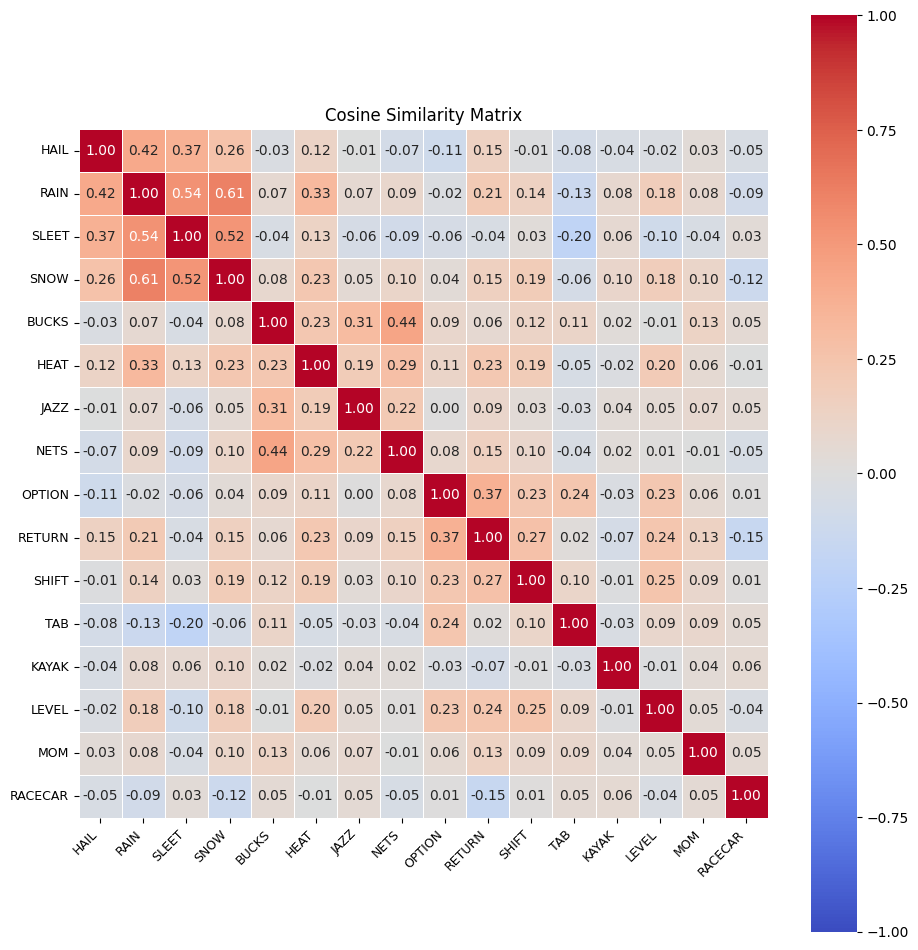

In [12]:
embedder = Embedder(words)

embedder.get_glove_embeddings()

similarity_matrix = embedder.get_cosine_similarity()

fig = embedder.plot_similarity_matrix()

## Ranking Word Combinations

Each puzzle contains 16 words that must be grouped into four-word categories. 
To evaluate possible groupings, we generated all possible four-word combinations and rank them by their average cosine similarity.

This allows us to determine how highly the correct NYT categories naturally appear using semantic similarity alone.

In [13]:
ranked_groups = rank_word_combinations(words, similarity_matrix)

ranked_groups.head(20)

,combo_words,combo_indices,mean_cosine_similarity
0,"(HAIL, RAIN, SLEET, SNOW)","(0, 1, 2, 3)",0.452395
1,"(RAIN, SLEET, SNOW, HEAT)","(1, 2, 3, 5)",0.390996
2,"(RAIN, SLEET, SNOW, SHIFT)","(1, 2, 3, 10)",0.337398
3,"(RAIN, SLEET, SNOW, RETURN)","(1, 2, 3, 9)",0.329706
4,"(HAIL, RAIN, SNOW, HEAT)","(0, 1, 3, 5)",0.327892
5,"(RAIN, SLEET, SNOW, LEVEL)","(1, 2, 3, 13)",0.319314
6,"(HAIL, RAIN, SLEET, HEAT)","(0, 1, 2, 5)",0.317802
7,"(RAIN, SLEET, SNOW, KAYAK)","(1, 2, 3, 12)",0.317405
8,"(RAIN, SLEET, SNOW, MOM)","(1, 2, 3, 14)",0.300440
9,"(HAIL, RAIN, SNOW, RETURN)","(0, 1, 3, 9)",0.299162


In [14]:
def get_true_groups(raw_puzzle):
    true_groups = []

    for answer in raw_puzzle["answers"]:
        true_groups.append(frozenset(answer["members"]))

    return true_groups

In [15]:
true_groups = get_true_groups(raw_puzzle)

ranked_groups["is_true_group"] = ranked_groups["combo_words"].apply(
    lambda x: frozenset(x) in true_groups
)

ranked_groups[ranked_groups["is_true_group"] == True]

,combo_words,combo_indices,mean_cosine_similarity,is_true_group
0,"(HAIL, RAIN, SLEET, SNOW)","(0, 1, 2, 3)",0.452395,True
16,"(BUCKS, HEAT, JAZZ, NETS)","(4, 5, 6, 7)",0.280209,True
80,"(OPTION, RETURN, SHIFT, TAB)","(8, 9, 10, 11)",0.205211,True
1517,"(KAYAK, LEVEL, MOM, RACECAR)","(12, 13, 14, 15)",0.024869,True


In [16]:
ranked_groups["rank"] = ranked_groups.index + 1

In [17]:
ranked_groups[ranked_groups["is_true_group"] == True]

,combo_words,combo_indices,mean_cosine_similarity,is_true_group,rank
0,"(HAIL, RAIN, SLEET, SNOW)","(0, 1, 2, 3)",0.452395,True,1
16,"(BUCKS, HEAT, JAZZ, NETS)","(4, 5, 6, 7)",0.280209,True,17
80,"(OPTION, RETURN, SHIFT, TAB)","(8, 9, 10, 11)",0.205211,True,81
1517,"(KAYAK, LEVEL, MOM, RACECAR)","(12, 13, 14, 15)",0.024869,True,1518


In [18]:
results = []

for puzzle_index in range(len(loader.words)):
    raw_puzzle = loader.get_puzzle(puzzle_index)
    words = loader.words[puzzle_index]

    embedder = Embedder(words)

    embedder.get_glove_embeddings()

    similarity_matrix = embedder.get_cosine_similarity()

    ranked_groups = rank_word_combinations(words, similarity_matrix)

    true_groups = get_true_groups(raw_puzzle)

    ranked_groups["is_true_group"] = ranked_groups["combo_words"].apply(
        lambda x: frozenset(x) in true_groups
    )

    ranked_groups["rank"] = ranked_groups.index + 1

    true_rankings = ranked_groups[ranked_groups["is_true_group"] == True][
        "rank"
    ].tolist()

    results.extend(true_rankings)

In [19]:
average_true_group_rank = np.mean(results)
median_true_group_rank = np.median(results)

best_ranked_true_group = min(results)
worst_ranked_true_group = max(results)

print(f"Average true-group rank: {average_true_group_rank:.2f}")
print(f"Median true-group rank: {median_true_group_rank:.2f}")
print(f"Best-ranked true group: {best_ranked_true_group}")
print(f"Worst-ranked true group: {worst_ranked_true_group}")

Average true-group rank: 619.52
Median true-group rank: 467.00
Best-ranked true group: 1
Worst-ranked true group: 1820


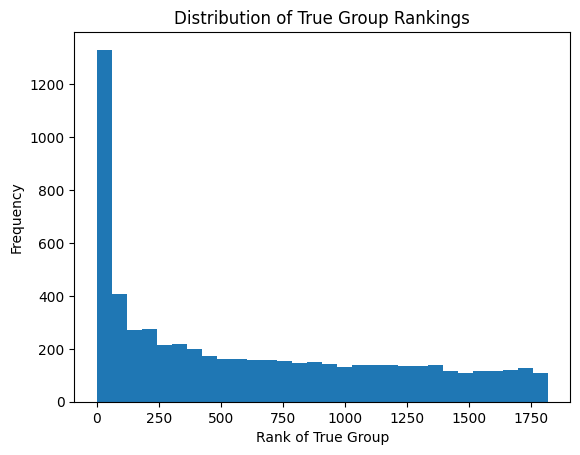

In [20]:
plt.hist(results, bins=30)
plt.xlabel("Rank of True Group")
plt.ylabel("Frequency")
plt.title("Distribution of True Group Rankings")
plt.show()

The distribution of true-group rankings is strongly right-skewed. Many correct categories ranked very highly using cosine similarity, indicating that semantic embeddings effectively capture meaning-based relationships between words.

However, a subset of categories ranked extremely poorly. These low-performing categories were often based on structural or contextual relationships rather than semantic meaning, such as palindromes or keyboard keys.

This demonstrates that embedding-based similarity can serve as a strong baseline for solving NYT Connections puzzles, but semantic similarity alone is insufficient for handling the full range of puzzle patterns used by the game.

## Playing the Game

Having established that cosine similarity rankings capture many true groups, we can now build a solver that attempts to identify all four categories for each puzzle.

The solver works iteratively: at each step it selects the highest-ranked four-word group from the remaining pool of words, removes those words, and repeats until four groups have been identified. The fourth group is determined automatically by the words that remain after three selections, which aligns with how the game is played (if three categories are solved, the fourth solves itself).

In [21]:
def solve_puzzle(words, similarity_matrix, true_groups):
    # Get the ranking of word combinations
    ranked = rank_word_combinations(words, similarity_matrix)

    # Get the index of each word
    remaining_indices = set(range(len(words)))
    predicted_groups = []

    for _ in range(3):
        valid = ranked[
            ranked["combo_indices"].apply(
                lambda idxs: set(idxs).issubset(remaining_indices)
            )
        ]

        if valid.empty:
            break

        best_row = valid.iloc[0]
        predicted_groups.append(frozenset(best_row["combo_words"]))
        remaining_indices -= set(best_row["combo_indices"])

    predicted_groups.append(frozenset(words[i] for i in remaining_indices))

    correct = sum(1 for g in predicted_groups if g in true_groups)
    return predicted_groups, correct

## Puzzle “Win”

Each NYT Connections puzzle contains four correct groups of four words.

Our solver progressively identifies groups and removes correctly matched words from the puzzle. A puzzle is considered a **win** when at least **three groups are correctly identified**.

We use this definition because once three groups are found, the remaining four words automatically form the final category.

Therefore:

- **0 correct groups** → Loss  
- **1–2 correct groups** → Partial success, but puzzle not solved  
- **3 correct groups** → Win (fourth group implied)  
- **4 correct groups** → Perfect solve  

This mirrors how the game is often played by humans, where identifying three categories effectively reveals the last remaining group.

In [22]:
solver_results = []

for puzzle_index in range(len(loader.words)):
    raw_puzzle = loader.get_puzzle(puzzle_index)
    words = loader.words[puzzle_index]

    embedder = Embedder(words)
    embedder.get_glove_embeddings()
    similarity_matrix = embedder.get_cosine_similarity()

    true_groups = get_true_groups(raw_puzzle)
    predicted_groups, correct = solve_puzzle(words, similarity_matrix, true_groups)

    solver_results.append(
        {"puzzle_index": puzzle_index, "correct_groups": correct, "win": correct >= 3}
    )

solver_df = pd.DataFrame(solver_results)

Wins: 27/1065
Win rate: 2.5%
Average correct groups per puzzle: 0.57


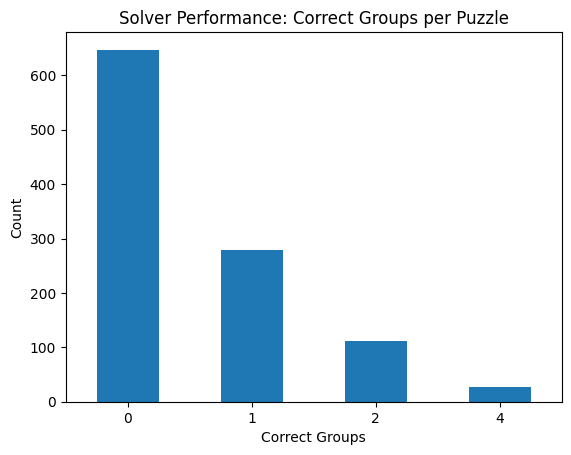

In [23]:
wins = solver_df["win"].sum()
total = len(solver_df)
win_rate = wins / total

print(f"Wins: {wins}/{total}")
print(f"Win rate: {win_rate:.1%}")
print(f"Average correct groups per puzzle: {solver_df['correct_groups'].mean():.2f}")

solver_df["correct_groups"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Correct Groups")
plt.ylabel("Count")
plt.title("Solver Performance: Correct Groups per Puzzle")
plt.xticks(rotation=0)
plt.show()

A 2% win rate is not very inspiring, but the challenge of the Connections game is that more than semantic meaning is used to group words; other aspects like structure or contextual groupings are fair game which our semantic similarity cannot capture.

While 2% may seem low, we can compare this metric to a random baseline to see if the solver is adding any value.

## Random Baseline

To contextualize the solver's performance, we establish a random baseline by repeatedly assigning the sixteen words to four groups at random. Each puzzle is evaluated over 700 random trials; the win rate and average correct groups are averaged across trials to produce a stable estimate.

In [27]:
N_TRIALS = 700
random_results = []

for puzzle_index in range(len(loader.words)):
    words = loader.words[puzzle_index]
    raw_puzzle = loader.get_puzzle(puzzle_index)
    true_groups = get_true_groups(raw_puzzle)

    wins = 0
    total_correct = 0

    for _ in range(N_TRIALS):
        shuffled = words[:]
        random.shuffle(shuffled)
        predicted = [frozenset(shuffled[i : i + 4]) for i in range(0, 16, 4)]
        correct = sum(1 for g in predicted if g in true_groups)
        total_correct += correct
        if correct >= 3:
            wins += 1

    random_results.append(
        {
            "puzzle_index": puzzle_index,
            "correct_groups": total_correct / N_TRIALS,
            "win_rate": wins / N_TRIALS,
        }
    )

random_df = pd.DataFrame(random_results)

                       Win Rate   Avg Correct Groups
Random Baseline            0.1%                 0.01
Cosine Solver              2.5%                 0.57


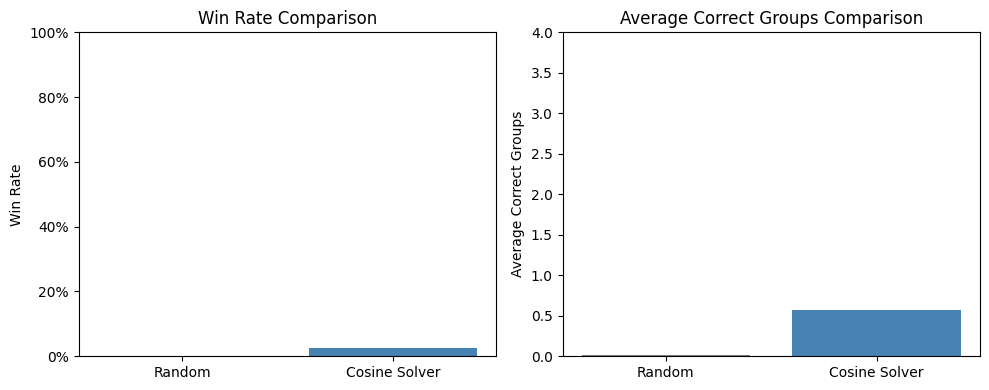

In [28]:
random_win_rate = random_df["win_rate"].mean()
random_avg_correct = random_df["correct_groups"].mean()

solver_win_rate = solver_df["win"].mean()
solver_avg_correct = solver_df["correct_groups"].mean()

print(f"{'':20} {'Win Rate':>10} {'Avg Correct Groups':>20}")
print(f"{'Random Baseline':20} {random_win_rate:>10.1%} {random_avg_correct:>20.2f}")
print(f"{'Cosine Solver':20} {solver_win_rate:>10.1%} {solver_avg_correct:>20.2f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(
    ["Random", "Cosine Solver"],
    [random_win_rate, solver_win_rate],
    color=["gray", "steelblue"],
)
axes[0].set_ylabel("Win Rate")
axes[0].set_title("Win Rate Comparison")
axes[0].set_ylim(0, 1)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

axes[1].bar(
    ["Random", "Cosine Solver"],
    [random_avg_correct, solver_avg_correct],
    color=["gray", "steelblue"],
)
axes[1].set_ylabel("Average Correct Groups")
axes[1].set_title("Average Correct Groups Comparison")
axes[1].set_ylim(0, 4)

fig.tight_layout()
plt.show()

Our cosine similarity does perform much better than random guessing, so this indicates that this approach is at least part of the solution to solving the puzzle. Additional steps that could be explored include different embeddings that focus on context, or evaluating the structure of words to try to capture patterns such as palindromes, prefixes, or other structural pattern based categories.

## Network Graph Approach

The cosine similarity matrix has a natural graph interpretation: each word is a node, and every pair of words is connected by an edge weighted by their cosine similarity. Words belonging to the same category should form dense, tightly-connected subgraphs, while cross-category connections should be weaker or absent.

Applying a similarity threshold to prune low-weight edges makes the community structure visible. Community detection algorithms can then partition the graph into groups that may correspond to the puzzle's four categories.

In [29]:
NYT_COLORS = {0: "#F9DF6D", 1: "#A0C35A", 2: "#B0C4EF", 3: "#BA81C5"}

puzzle_index = 0

raw_puzzle = loader.get_puzzle(puzzle_index)
words = loader.words[puzzle_index]

embedder = Embedder(words)
embedder.get_glove_embeddings()
similarity_matrix = embedder.get_cosine_similarity()

word_color = {}
for answer in raw_puzzle["answers"]:
    for word in answer["members"]:
        word_color[word] = NYT_COLORS[answer["level"]]

G = nx.Graph()
G.add_nodes_from(words)

threshold = 0.3

for i in range(len(words)):
    for j in range(i + 1, len(words)):
        weight = float(similarity_matrix[i, j])
        if weight > threshold:
            G.add_edge(words[i], words[j], weight=weight)

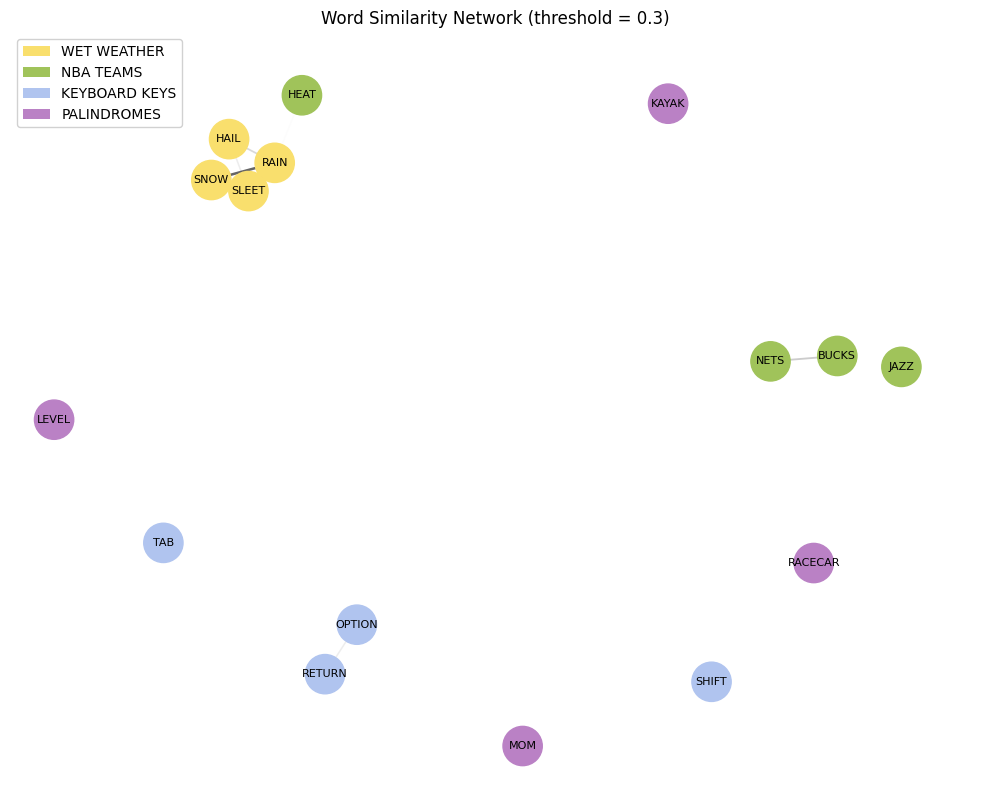

In [30]:
fig, ax = plt.subplots(figsize=(10, 8))

pos = nx.spring_layout(G, seed=42)
node_colors = [word_color[w] for w in G.nodes()]
edge_weights = [G[u][v]["weight"] for u, v in G.edges()]

nx.draw_networkx_nodes(G, pos, node_size=800, node_color=node_colors, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, font_color="black", ax=ax)
nx.draw_networkx_edges(
    G,
    pos,
    width=[w * 3 for w in edge_weights],
    alpha=0.6,
    edge_color=edge_weights,
    edge_cmap=plt.cm.Greys,
    ax=ax,
)

legend_handles = [
    Patch(facecolor=NYT_COLORS[answer["level"]], label=answer["group"])
    for answer in raw_puzzle["answers"]
]
ax.legend(handles=legend_handles, loc="upper left", framealpha=0.9)

ax.set_title(f"Word Similarity Network (threshold = {threshold})")
ax.axis("off")
fig.tight_layout()
plt.show()

The network graph reveals clusters of semantically related words that emerge naturally from the cosine similarity structure. Words within the same true category tend to form visible communities, connected by strong edges, while cross-category edges are weaker or absent entirely.

This representation opens the door to community detection as a grouping strategy. Rather than simply selecting the top-ranked combination, a community detection pass over the graph would identify all four groups simultaneously—potentially capturing categories that are individually less salient but collectively well-separated. 

This approach is also extensible: edges could incorporate multiple similarity signals beyond cosine similarity, such as structural or phonetic features, making the graph a natural integration point for the combined embedding-plus-network strategy described in our original hypothesis.

## Limitations

- This approach relies heavily on semantic similarity, so it performs best on categories where words are related by meaning.
- The model struggles with categories based on:
  - spelling patterns
  - word structure
  - abbreviations
  - pop culture references
  - fill-in-the-blank style relationships
- Word embeddings do not effectively capture many forms of wordplay commonly used in NYT Connections puzzles.
- The network graph component currently serves primarily as a visualization and interpretation tool rather than a fully evaluated community detection solver.
- Cosine similarity alone is not sufficient to fully solve all puzzle types, especially categories that depend more on structure or context than semantics.

## Conclusion

Our simple semantic model certainly does not improve upon human ability, but it demonstrates the complexity of words and how there are many different vector spaces available to us when measuring similarity. Still, the semantic embeddings gave us some signal, and while its win rate was low, it did perform well in the categories where semantic similarity was sought after.

The network approach is how we scale; instead of single edges of semantic cosine similarity, we get the option to add additional edges representing other vectors. Then, network algorithms unlock the ability to find neighbors by any combination of those edges, giving us a dynamic and more complete view of word associations.

Overall, these approaches show promise that a full model could be developed to solve these word puzzles - an interesting challenge in itself!